# 교차 검증과 그리드 서치

## 훈련셋 -> 테스트 셋, 과대적합/과소적합 판단 시 테스트 셋으로 판단하므로, 테스트 셋에 적합한 모델이 학습된다.
   - 테스트 셋으로 검증하고, 다시 훈련
## 훈련셋 -> 검증 셋으로 과대/과소 적합 판정 진행하고, 최종 테스트 셋 범용성을 판단한다

## 데이터가 커야 한다.

## 주로 딥러닝처럼 데이터가 클 때 사용한다

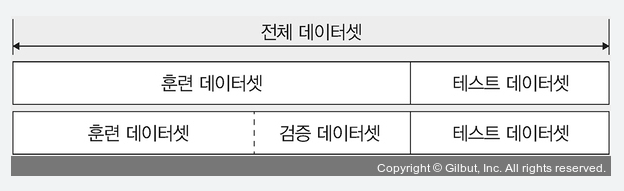

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/rickiepark/hg-mldl/blob/master/5-2.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />구글 코랩에서 실행하기</a>
  </td>
</table>

## 검증 세트

In [2]:
import pandas as pd

wine = pd.read_csv('wine.csv')
wine

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0
...,...,...,...,...
6492,11.2,1.6,3.27,1.0
6493,9.6,8.0,3.15,1.0
6494,9.4,1.2,2.99,1.0
6495,12.8,1.1,3.34,1.0


In [4]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [3]:
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

print(data.shape)
print(target.shape)

(6497, 3)
(6497,)


In [6]:
from sklearn.model_selection import train_test_split

# 훈련셋과 테스트 셋 분할
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)

In [7]:
# 훈련셋에서 검증셋을 분할
sub_input, val_input, sub_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

In [9]:
print(sub_input.shape, val_input.shape,  test_input.shape)

(4157, 3) (1040, 3) (1300, 3)


In [10]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(sub_input, sub_target)

print(dt.score(sub_input, sub_target))
print(dt.score(val_input, val_target))

0.9971133028626413
0.864423076923077


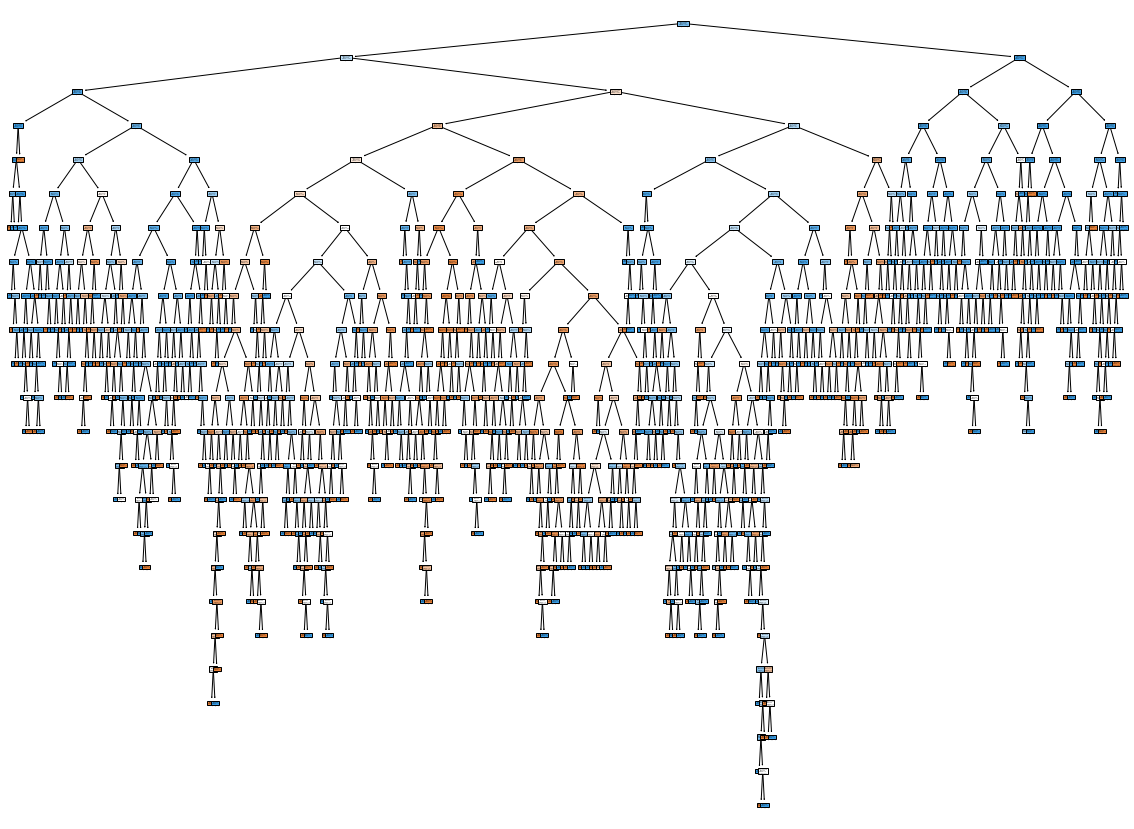

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

## 교차 검증

- 머신러닝은 딥러닝처럼 데이터가 많지 않을 수도 있다.
- 이럴 때는 K-폴드 교차 검증을 사용해서 데이터의 임의성을 높인다.
- 지나친 과적합을 방지하고 임의성을 줄 수 있어서 학습기의 보편성을 향상시킨다.
- 데이터가 많지 않은 머신러닝에서 주로 사용하는 방법이다

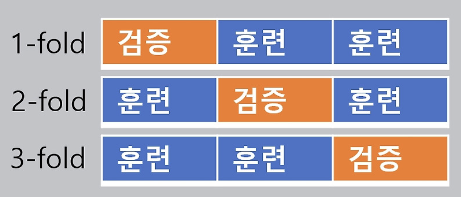

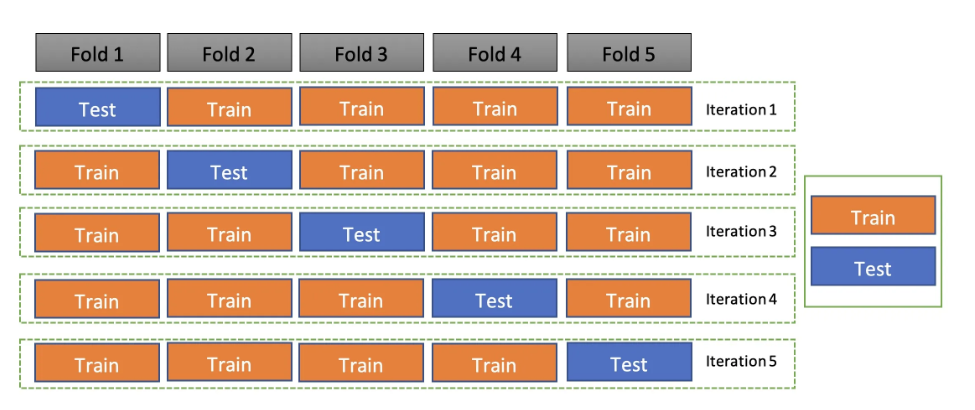

In [12]:
from sklearn.model_selection import cross_validate

scores = cross_validate(dt, train_input, train_target)
# fit_time : 훈련시간
# score_time : 검증시간
# test_score : 검증 점수, 각 interation당 Test점수
print(scores)

{'fit_time': array([0.        , 0.00774574, 0.00883174, 0.        , 0.01090741]), 'score_time': array([0., 0., 0., 0., 0.]), 'test_score': array([0.86923077, 0.84615385, 0.87680462, 0.84889317, 0.83541867])}


In [13]:
import numpy as np

print(np.mean(scores['test_score']))

0.855300214703487


In [15]:
from sklearn.model_selection import StratifiedKFold

scores = cross_validate(dt, train_input, train_target, cv=StratifiedKFold())
print(np.mean(scores['test_score']))

0.855300214703487


In [16]:
splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_validate(dt, train_input, train_target, cv=splitter)
print(np.mean(scores['test_score']))

0.8574181117533719


## 하이퍼파라미터 튜닝

In [18]:
from sklearn.model_selection import GridSearchCV

params = {'min_impurity_decrease': [0.0001, 0.0002, 0.0003, 0.0004, 0.0005]}

## Grid search 란 무엇인가?
- 모델에게 가장 적합한 하이퍼 파라미터를 찾기 
- 그리드 서치는 그 세부적인 규율을 일일히 다 적용해봐가면서, 어떤 규율이 가장 이 공부법(모델)에 적합한지 판단하는 것이다. 
- 모든 조합을 테스트 해본다
- 속도가 느리다

In [19]:
# 기본 cv=5이다
# cv는 cross_validate, 5폴드 교차 검증
# cv=5 * params=5 = 25개를 모두 테스트 진행
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1)

In [20]:
gs.fit(train_input, train_target)

GridSearchCV(cv=None, error_score=nan,
             estimator=DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features=None,
                                              max_leaf_nodes=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              presort='deprecated',
                                              random_state=42,
                                              splitter='best'),
             iid='deprecated', n_jobs=-1,
             param_grid={'min_impurity_decrease': [0.0001, 0.0002, 0.0003,
    

In [24]:
# 모든 경우 중에 가장 좋은 dt객체를 리턴
dt = gs.best_estimator_
print(dt.score(train_input, train_target))

0.9615162593804117


In [25]:
print(gs.best_params_)

{'min_impurity_decrease': 0.0001}


In [16]:
print(gs.cv_results_['mean_test_score'])

[0.86819297 0.86453617 0.86492226 0.86780891 0.86761605]


In [17]:
best_index = np.argmax(gs.cv_results_['mean_test_score'])
print(gs.cv_results_['params'][best_index])

{'min_impurity_decrease': 0.0001}


In [27]:
# min_impurity_decrease : 불순도 감소 최소량
# max_depth             : 트리의 최대 깊이
# min_samples_split     : 노드 분할 최소 샘플 수

params = {'min_impurity_decrease': np.arange(0.0001, 0.001, 0.0001),    # 10개 경우
          'max_depth': range(5, 20, 1),                                 # 15개 경우
          'min_samples_split': range(2, 100, 10)                        # 9개 경우
          }

# GridSearch 검증 경우의 수는 5fold * 10 * 15 * 9

In [28]:
print(5 * 10 * 15 * 9)

6750


In [29]:
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), params, n_jobs=-1)
gs.fit(train_input, train_target)

GridSearchCV(cv=None, error_score=nan,
             estimator=DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features=None,
                                              max_leaf_nodes=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              presort='deprecated',
                                              random_state=42,
                                              splitter='best'),
             iid='deprecated', n_jobs=-1,
             param_grid={'max_depth': range(5, 20),
                         'm

In [30]:
print(gs.best_params_)

{'max_depth': 14, 'min_impurity_decrease': 0.0004, 'min_samples_split': 12}


In [31]:
print(np.max(gs.cv_results_['mean_test_score']))

0.8683865773302731


## 그리드 서치는 모든 경우를 하므로 시간이 소요될 수 있다
## 랜덤 서치를 통해 시간을 빠르게 진행한다

### 랜덤 서치

In [34]:
# 범위 내에서 균등하게 난수 생성
from scipy.stats import uniform, randint

In [35]:
rgen = randint(0, 10)
rgen.rvs(10)

array([2, 4, 1, 3, 7, 2, 8, 6, 9, 4])

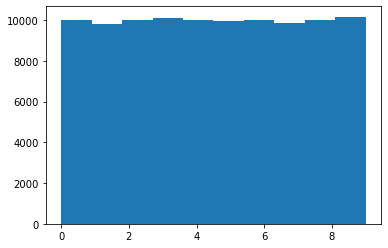

In [39]:
rtest =  np.unique(rgen.rvs(100000), return_counts=True)

import matplotlib.pyplot as plt

plt.hist(weights=rtest[1], x=rtest[0])
plt.show()

In [40]:
ugen = uniform(0, 1)
ugen.rvs(10)

array([0.65637629, 0.10472609, 0.08360162, 0.29846133, 0.1715753 ,
       0.98969705, 0.46664143, 0.52963071, 0.50406853, 0.17922146])

In [41]:
params = {'min_impurity_decrease': uniform(0.0001, 0.001),
          'max_depth': randint(20, 50),
          'min_samples_split': randint(2, 25),
          'min_samples_leaf': randint(1, 25),
          }

In [42]:
from sklearn.model_selection import RandomizedSearchCV

gs = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), params,
                        n_iter=100, n_jobs=-1, random_state=42)
gs.fit(train_input, train_target)

RandomizedSearchCV(cv=None, error_score=nan,
                   estimator=DecisionTreeClassifier(ccp_alpha=0.0,
                                                    class_weight=None,
                                                    criterion='gini',
                                                    max_depth=None,
                                                    max_features=None,
                                                    max_leaf_nodes=None,
                                                    min_impurity_decrease=0.0,
                                                    min_impurity_split=None,
                                                    min_samples_leaf=1,
                                                    min_samples_split=2,
                                                    min_weight_fraction_leaf=0.0,
                                                    presort='deprecated',
                                                    random_state=42,
         

In [43]:
print(gs.best_params_)

{'max_depth': 39, 'min_impurity_decrease': 0.00034102546602601173, 'min_samples_leaf': 7, 'min_samples_split': 13}


In [44]:
print(np.max(gs.cv_results_['mean_test_score']))

0.8695428296438884


In [45]:
dt = gs.best_estimator_

print(dt.score(test_input, test_target))

0.86


## 확인문제

In [46]:
gs = RandomizedSearchCV(DecisionTreeClassifier(splitter='random', random_state=42), params,
                        n_iter=100, n_jobs=-1, random_state=42)
gs.fit(train_input, train_target)

RandomizedSearchCV(cv=None, error_score=nan,
                   estimator=DecisionTreeClassifier(ccp_alpha=0.0,
                                                    class_weight=None,
                                                    criterion='gini',
                                                    max_depth=None,
                                                    max_features=None,
                                                    max_leaf_nodes=None,
                                                    min_impurity_decrease=0.0,
                                                    min_impurity_split=None,
                                                    min_samples_leaf=1,
                                                    min_samples_split=2,
                                                    min_weight_fraction_leaf=0.0,
                                                    presort='deprecated',
                                                    random_state=42,
         

In [47]:
print(gs.best_params_)
print(np.max(gs.cv_results_['mean_test_score']))

dt = gs.best_estimator_
print(dt.score(test_input, test_target))

{'max_depth': 43, 'min_impurity_decrease': 0.00011407982271508446, 'min_samples_leaf': 19, 'min_samples_split': 18}
0.8458726956392981
0.786923076923077
